# TRAIN MODEL

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("../data/train/train_data.csv")

### Kiểm tra qua các data

In [4]:
df.head()

,location_id,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood,month,rainfall_3d,rainfall_7d,discharge_change_1d,target_d1,target_d2,target_d3
0,1,2001-07-07,0.5,30.200001,68.0,998.400024,23.1,0.36,0,7,0.5,16.3,-0.01,0,0,0
1,1,2001-07-08,38.0,28.400000,82.0,1003.099976,6.2,0.70,0,7,38.5,54.3,0.34,0,0,0
2,1,2001-07-09,6.7,28.000000,80.0,1006.400024,8.1,1.28,0,7,45.2,60.8,0.58,0,0,0
3,1,2001-07-10,0.2,28.200001,79.0,1006.200012,9.2,0.92,0,7,44.9,59.2,-0.36,0,0,0
4,1,2001-07-11,0.8,28.600000,80.0,1004.700012,9.1,0.58,0,7,7.7,46.2,-0.34,0,0,0


In [5]:
df.shape

(18268, 16)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18268 entries, 0 to 18267
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   location_id          18268 non-null  int64  
 1   date                 18268 non-null  str    
 2   rainfall             18268 non-null  float64
 3   temperature          18268 non-null  float64
 4   humidity             18268 non-null  float64
 5   pressure             18268 non-null  float64
 6   wind_speed           18268 non-null  float64
 7   river_discharge      18268 non-null  float64
 8   flood                18268 non-null  int64  
 9   month                18268 non-null  int64  
 10  rainfall_3d          18268 non-null  float64
 11  rainfall_7d          18268 non-null  float64
 12  discharge_change_1d  18268 non-null  float64
 13  target_d1            18268 non-null  int64  
 14  target_d2            18268 non-null  int64  
 15  target_d3            18268 non-null  int64  
dt

In [7]:
df['date'] = pd.to_datetime(df['date'])

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18268 entries, 0 to 18267
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   location_id          18268 non-null  int64         
 1   date                 18268 non-null  datetime64[us]
 2   rainfall             18268 non-null  float64       
 3   temperature          18268 non-null  float64       
 4   humidity             18268 non-null  float64       
 5   pressure             18268 non-null  float64       
 6   wind_speed           18268 non-null  float64       
 7   river_discharge      18268 non-null  float64       
 8   flood                18268 non-null  int64         
 9   month                18268 non-null  int64         
 10  rainfall_3d          18268 non-null  float64       
 11  rainfall_7d          18268 non-null  float64       
 12  discharge_change_1d  18268 non-null  float64       
 13  target_d1            18268 non-null  int64

In [8]:
df.isnull().sum()

location_id            0
date                   0
rainfall               0
temperature            0
humidity               0
pressure               0
wind_speed             0
river_discharge        0
flood                  0
month                  0
rainfall_3d            0
rainfall_7d            0
discharge_change_1d    0
target_d1              0
target_d2              0
target_d3              0
dtype: int64

In [9]:
df.describe()

,location_id,date,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,flood,month,rainfall_3d,rainfall_7d,discharge_change_1d,target_d1,target_d2,target_d3
count,18268.000000,18268,18268.000000,18268.000000,18268.000000,18268.000000,18268.000000,18268.000000,18268.000000,18268.000000,18268.000000,18268.000000,18268.000000,18268.000000,18268.000000,18268.000000
mean,1.500000,2014-01-06 12:00:00,7.881476,25.754899,83.024578,1009.353979,14.336813,23.604211,0.175881,6.523210,23.643831,55.168508,-0.000217,0.175881,0.175881,0.175881
min,1.000000,2001-07-07 00:00:00,0.000000,14.100000,45.000000,984.400024,4.200000,0.080000,0.000000,1.000000,0.000000,0.000000,-776.870056,0.000000,0.000000,0.000000
25%,1.000000,2007-10-07 00:00:00,0.200000,23.299999,80.000000,1005.299988,11.300000,0.670000,0.000000,4.000000,2.300000,11.700000,-0.740000,0.000000,0.000000,0.000000
50%,1.500000,2014-01-06 12:00:00,2.200000,26.000000,84.000000,1009.000000,13.600000,6.530000,0.000000,7.000000,10.000000,30.900000,-0.040000,0.000000,0.000000,0.000000
75%,2.000000,2020-04-08 00:00:00,8.400000,28.400000,88.000000,1013.299988,16.600000,14.850000,0.000000,10.000000,27.900000,69.699999,0.200000,0.000000,0.000000,0.000000
max,2.000000,2026-07-09 00:00:00,398.799988,34.599998,97.000000,1028.400024,64.599998,1569.359985,1.000000,12.000000,578.099998,692.799995,815.269958,1.000000,1.000000,1.000000
std,0.500014,NaN,16.879654,3.284748,7.054209,5.195090,4.611414,68.819440,0.380730,3.448208,39.209398,71.653708,37.931722,0.380730,0.380730,0.380730


## Chia X y

In [10]:
feature_cols = [
    'location_id', 
    'rainfall', 
    'temperature', 
    'humidity',
    'pressure', 
    'wind_speed', 
    'river_discharge',
    'month',
    'rainfall_3d', 
    'rainfall_7d', 
    'discharge_change_1d'
]

X = df[feature_cols]
X.head()

,location_id,rainfall,temperature,humidity,pressure,wind_speed,river_discharge,month,rainfall_3d,rainfall_7d,discharge_change_1d
0,1,0.5,30.200001,68.0,998.400024,23.1,0.36,7,0.5,16.3,-0.01
1,1,38.0,28.400000,82.0,1003.099976,6.2,0.70,7,38.5,54.3,0.34
2,1,6.7,28.000000,80.0,1006.400024,8.1,1.28,7,45.2,60.8,0.58
3,1,0.2,28.200001,79.0,1006.200012,9.2,0.92,7,44.9,59.2,-0.36
4,1,0.8,28.600000,80.0,1004.700012,9.1,0.58,7,7.7,46.2,-0.34


In [11]:
target_cols = [
    'target_d1',
    'target_d2',
    'target_d3'
]

y = df[target_cols]
y.head()

,target_d1,target_d2,target_d3
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0


In [12]:
cutoff_date = pd.Timestamp("2023-01-01")

train_mask = df["date"] < cutoff_date
test_mask = df['date'] >= cutoff_date

In [13]:
X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()

y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

In [14]:
print("Tỷ lệ lũ trong tập train:")

print(y_train.mean().mul(100).round(2))

print("\nTỷ lệ lũ trong tập test:")

print(y_test.mean().mul(100).round(2))

Tỷ lệ lũ trong tập train:
target_d1    17.88
target_d2    17.88
target_d3    17.89
dtype: float64

Tỷ lệ lũ trong tập test:
target_d1    15.82
target_d2    15.82
target_d3    15.75
dtype: float64


- Dữ liệu mất cân bằng -> Accuracy có thể chưa chính xác

### Train models 

`RandomForestClassifier` và `XGBoost`

In [15]:
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt
import pandas as pd
import joblib

Tạo nơi lưu model và kết quả

# RandomForest

In [16]:
rf_models = {}
rf_results = []
rf_predictions = {}
rf_probabilities = {}

In [17]:
for target in target_cols:

    print("=" * 60)
    print("Đang train model:", target)

    model = RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train[target]
    )

    rf_models[target] = model

    print("Đã train xong:", target)

Đang train model: target_d1
Đã train xong: target_d1
Đang train model: target_d2
Đã train xong: target_d2
Đang train model: target_d3
Đã train xong: target_d3


In [18]:
for target in target_cols:

    model = rf_models[target]

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:, 1]

    rf_predictions[target] = y_pred
    rf_probabilities[target] = y_prob

In [19]:
rf_results = []

for target in target_cols:

    y_true = y_test[target]

    y_pred = rf_predictions[target]

    y_prob = rf_probabilities[target]

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    tn, fp, fn, tp = cm.ravel()

    rf_result = {
        "model": "Random Forest",
        "target": target,

        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "recall": recall_score(
            y_true,

            y_pred,
            zero_division=0
        ),

        "f1_score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "roc_auc": roc_auc_score(
            y_true,
            y_prob
        ),

        "pr_auc": average_precision_score(
            y_true,
            y_prob
        ),

        "true_negative": tn,
        "false_positive": fp,
        "false_negative": fn,
        "true_positive": tp
    }

    rf_results.append(rf_result)

In [20]:
rf_results_df = pd.DataFrame(rf_results)

rf_results_df.round(4)

,model,target,accuracy,precision,recall,f1_score,roc_auc,pr_auc,true_negative,false_positive,false_negative,true_positive
0,Random Forest,target_d1,0.9343,0.8306,0.7346,0.7797,0.9652,0.8695,2104,61,108,299
1,Random Forest,target_d2,0.8993,0.7312,0.5749,0.6437,0.9192,0.7412,2079,86,173,234
2,Random Forest,target_d3,0.8616,0.5866,0.4099,0.4826,0.8657,0.5600,2050,117,239,166


Accuracy:

(TP + TN)/(TP + TN + FP + FN)

Precision: Trong những ngày cảnh báo lũ, bao nhiêu ngày thực sự có lũ

TP/(TP + FP)

Recall: Trong toàn bộ ngày thực sự có lũ, model phát hiện được bao nhiêu

TP/(TP + FN)

F1 Score: cân bằng giữa Precision và Recall

F1 khi muốn model vừa: Cảnh báo tương đối chính xác, Không bỏ sót quá nhiều ngày lũ

2*(Precision*Recall)/(Precision + Recall)



In [21]:
for target in target_cols:

    print("=" * 70)
    print("KẾT QUẢ:", target)
    print("=" * 70)

    print(
        classification_report(
            y_test[target],
            rf_predictions[target],
            target_names=[
                "Không lũ",
                "Có lũ"
            ],
            zero_division=0
        )
    )

KẾT QUẢ: target_d1
              precision    recall  f1-score   support

    Không lũ       0.95      0.97      0.96      2165
       Có lũ       0.83      0.73      0.78       407

    accuracy                           0.93      2572
   macro avg       0.89      0.85      0.87      2572
weighted avg       0.93      0.93      0.93      2572

KẾT QUẢ: target_d2
              precision    recall  f1-score   support

    Không lũ       0.92      0.96      0.94      2165
       Có lũ       0.73      0.57      0.64       407

    accuracy                           0.90      2572
   macro avg       0.83      0.77      0.79      2572
weighted avg       0.89      0.90      0.89      2572

KẾT QUẢ: target_d3
              precision    recall  f1-score   support

    Không lũ       0.90      0.95      0.92      2167
       Có lũ       0.59      0.41      0.48       405

    accuracy                           0.86      2572
   macro avg       0.74      0.68      0.70      2572
weighted avg     

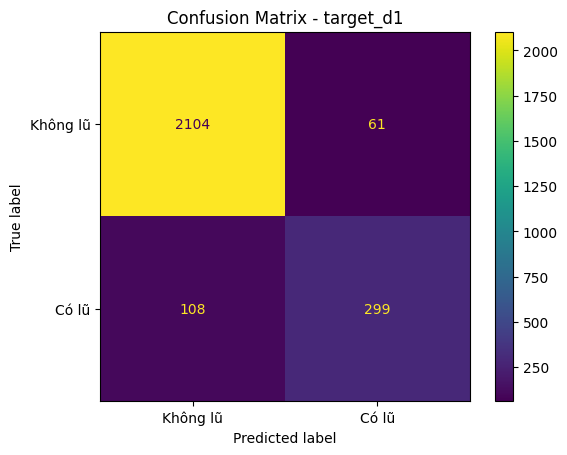

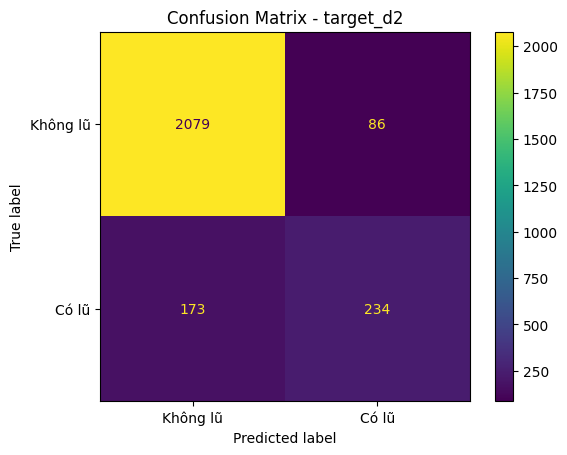

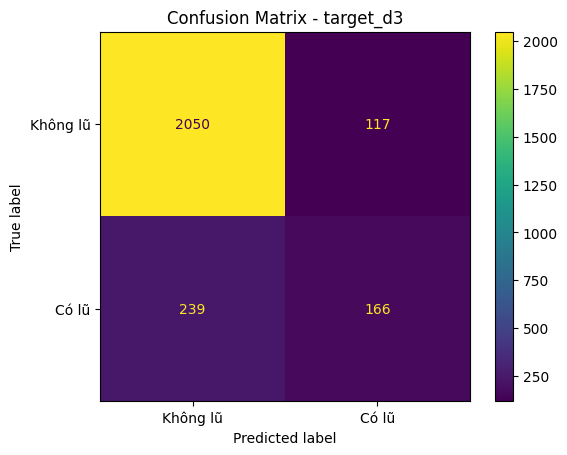

In [22]:
for target in target_cols:
    ConfusionMatrixDisplay.from_predictions(
        y_test[target],
        rf_predictions[target],
        display_labels=[
            "Không lũ",
            "Có lũ"
        ]
    )

    plt.title(
        f"Confusion Matrix - {target}"
    )

    plt.show()

Ý nghĩa:

* TN: không lũ và model đoán không lũ.
* TP: có lũ và model đoán có lũ.
* FP: không lũ nhưng model cảnh báo lũ.
* FN: có lũ nhưng model không cảnh báo.

Trong dự báo lũ, trường hợp nguy hiểm nhất là `FN`

In [23]:
feature_importance_tables = {}

for target in target_cols:

    model = rf_models[target]

    importance_df = pd.DataFrame({
        "feature": X_train.columns,
        "importance": model.feature_importances_
    })

    importance_df = importance_df.sort_values(
        by="importance",
        ascending=False
    )

    feature_importance_tables[target] = importance_df

    print("=" * 60)
    print("Feature Importance:", target)

    display(importance_df)

Feature Importance: target_d1


,feature,importance
1,rainfall,0.214981
8,rainfall_3d,0.152406
9,rainfall_7d,0.130117
10,discharge_change_1d,0.102983
7,month,0.094495
6,river_discharge,0.093362
2,temperature,0.059411
4,pressure,0.049818
5,wind_speed,0.048770
3,humidity,0.047064


Feature Importance: target_d2


,feature,importance
7,month,0.164564
1,rainfall,0.142074
9,rainfall_7d,0.113346
8,rainfall_3d,0.111839
6,river_discharge,0.093169
10,discharge_change_1d,0.088088
2,temperature,0.086755
4,pressure,0.070724
5,wind_speed,0.067484
3,humidity,0.056724


Feature Importance: target_d3


,feature,importance
7,month,0.188849
9,rainfall_7d,0.123289
8,rainfall_3d,0.104877
6,river_discharge,0.099178
2,temperature,0.093407
1,rainfall,0.089862
4,pressure,0.082261
10,discharge_change_1d,0.079638
5,wind_speed,0.074835
3,humidity,0.058413


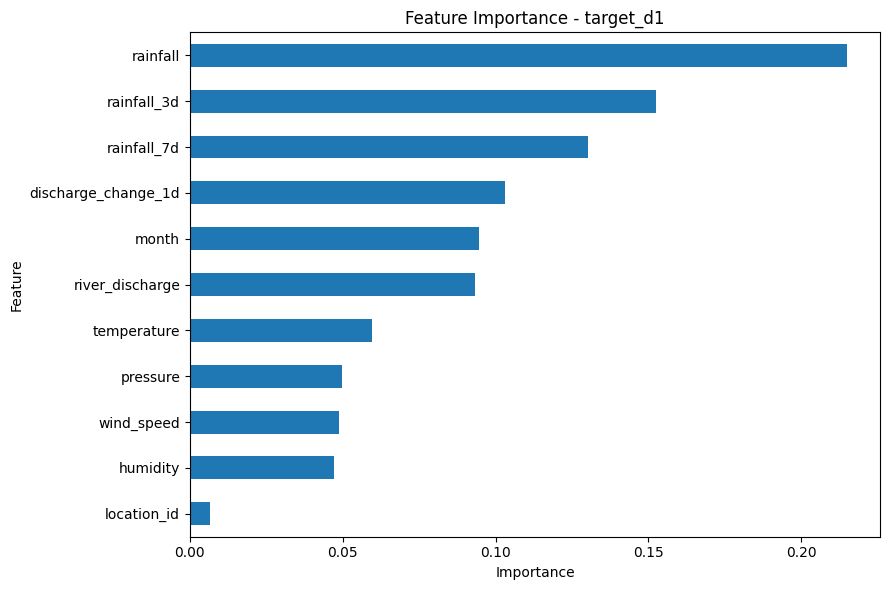

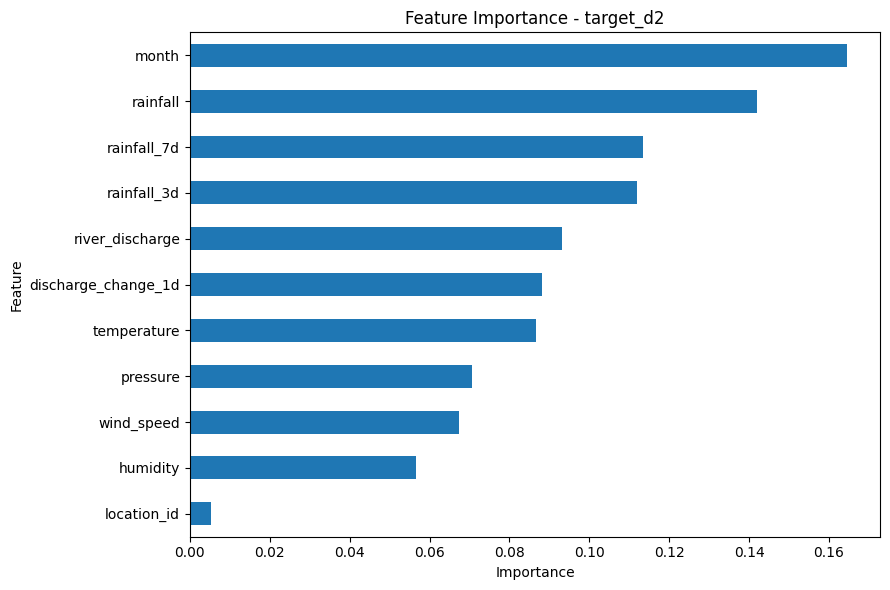

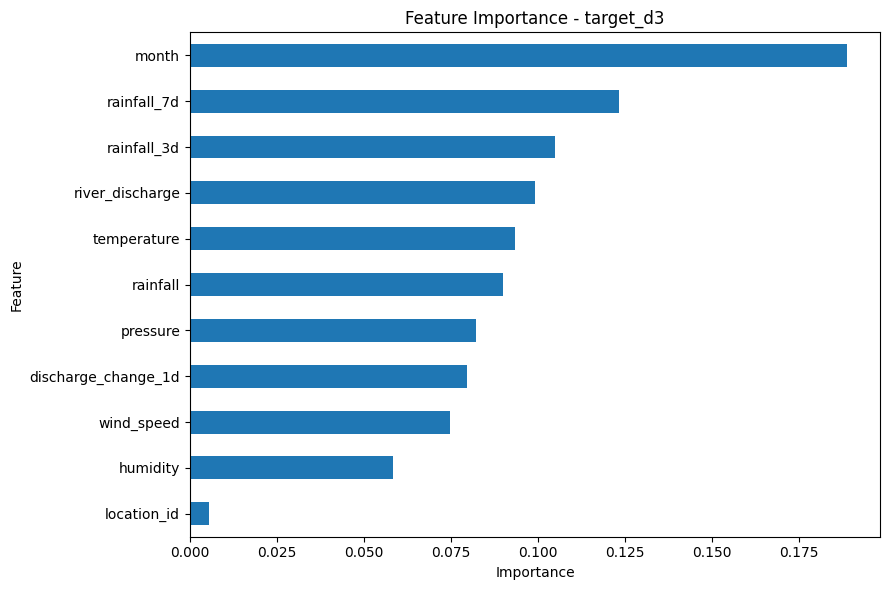

In [24]:
for target in target_cols:

    importance_df = (
        feature_importance_tables[target]
        .sort_values(
            by="importance",
            ascending=True
        )
    )

    importance_df.plot(
        kind="barh",
        x="feature",
        y="importance",
        figsize=(9, 6),
        legend=False
    )

    plt.title(
        f"Feature Importance - {target}"
    )

    plt.xlabel("Importance")

    plt.ylabel("Feature")

    plt.tight_layout()

    plt.show()

# XGBoost

In [25]:
scale_pos_weights = {}

for target in target_cols:

    negative_count = (
        y_train[target] == 0
    ).sum()

    positive_count = (
        y_train[target] == 1
    ).sum()

    scale_pos_weights[target] = (
        negative_count / positive_count
    )

scale_pos_weights

{'target_d1': np.float64(4.593727726300784),
 'target_d2': np.float64(4.593727726300784),
 'target_d3': np.float64(4.589743589743589)}

In [26]:
xgb_models = {}
xgb_predictions = {}
xgb_probabilities = {}
xgb_results = []

In [27]:
for target in target_cols:

    print("=" * 60)
    print("Đang train XGBoost:", target)

    model = XGBClassifier(
        n_estimators=300, #Tạo 300 cây liên tiếp
        max_depth=6, # giới hạn độ sâu của cây
        learning_rate=0.05, # mỗi cây sửa lỗi một lượng nhỏ

        subsample=0.8, # mỗi cây dùng 80% mẫu
        colsample_bytree=0.8, #mỗi cây dùng 80% feature

        scale_pos_weight=scale_pos_weights[target],

        objective="binary:logistic",
        eval_metric="logloss",

        random_state=42,
        n_jobs=-1
    )

    model.fit(
        X_train,
        y_train[target]
    )

    xgb_models[target] = model

    print("Đã train XGBoost:", target)

Đang train XGBoost: target_d1
Đã train XGBoost: target_d1
Đang train XGBoost: target_d2
Đã train XGBoost: target_d2
Đang train XGBoost: target_d3
Đã train XGBoost: target_d3


In [28]:
for target in target_cols:

    model = xgb_models[target]

    xgb_predictions[target] = model.predict(
        X_test
    )

    xgb_probabilities[target] = model.predict_proba(
        X_test
    )[:, 1]

In [29]:
xgb_results = []

for target in target_cols:

    y_true = y_test[target]

    y_pred = xgb_predictions[target]

    y_prob = xgb_probabilities[target]

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred
    ).ravel()

    xgb_results.append({
        "model": "XGBoost",
        "target": target,

        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),

        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "f1_score": f1_score(
            y_true,
            y_pred,
            zero_division=0
        ),

        "roc_auc": roc_auc_score(
            y_true,
            y_prob
        ),

        "pr_auc": average_precision_score(
            y_true,
            y_prob
        ),

        "true_negative": tn,
        "false_positive": fp,
        "false_negative": fn,
        "true_positive": tp
    })

In [30]:
xgb_results_df = pd.DataFrame(
    xgb_results
)

xgb_results_df.round(4)

,model,target,accuracy,precision,recall,f1_score,roc_auc,pr_auc,true_negative,false_positive,false_negative,true_positive
0,XGBoost,target_d1,0.9086,0.6581,0.8796,0.7529,0.9648,0.8730,1979,186,49,358
1,XGBoost,target_d2,0.8713,0.5640,0.8231,0.6693,0.9253,0.7556,1906,259,72,335
2,XGBoost,target_d3,0.8247,0.4648,0.7506,0.5741,0.8695,0.5699,1817,350,101,304


In [31]:
for target in target_cols:

    print("=" * 70)
    print("XGBOOST:", target)
    print("=" * 70)

    print(
        classification_report(
            y_test[target],
            xgb_predictions[target],
            target_names=[
                "Không lũ",
                "Có lũ"
            ],
            zero_division=0
        )
    )

XGBOOST: target_d1
              precision    recall  f1-score   support

    Không lũ       0.98      0.91      0.94      2165
       Có lũ       0.66      0.88      0.75       407

    accuracy                           0.91      2572
   macro avg       0.82      0.90      0.85      2572
weighted avg       0.93      0.91      0.91      2572

XGBOOST: target_d2
              precision    recall  f1-score   support

    Không lũ       0.96      0.88      0.92      2165
       Có lũ       0.56      0.82      0.67       407

    accuracy                           0.87      2572
   macro avg       0.76      0.85      0.79      2572
weighted avg       0.90      0.87      0.88      2572

XGBOOST: target_d3
              precision    recall  f1-score   support

    Không lũ       0.95      0.84      0.89      2167
       Có lũ       0.46      0.75      0.57       405

    accuracy                           0.82      2572
   macro avg       0.71      0.79      0.73      2572
weighted avg     

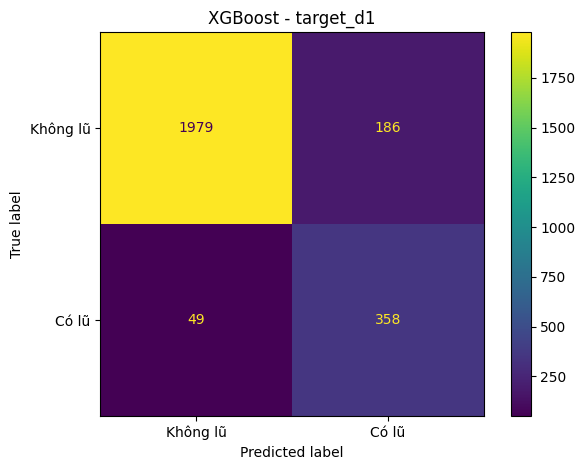

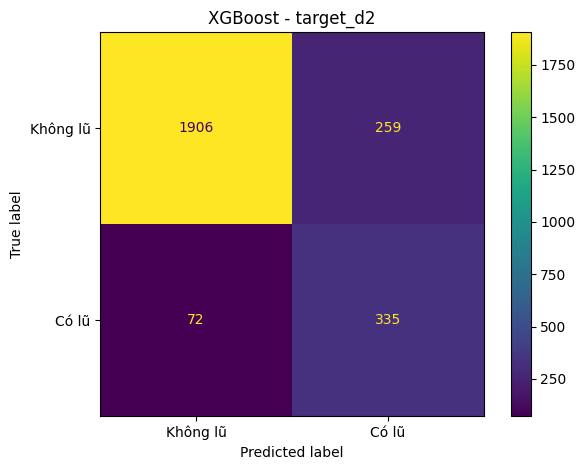

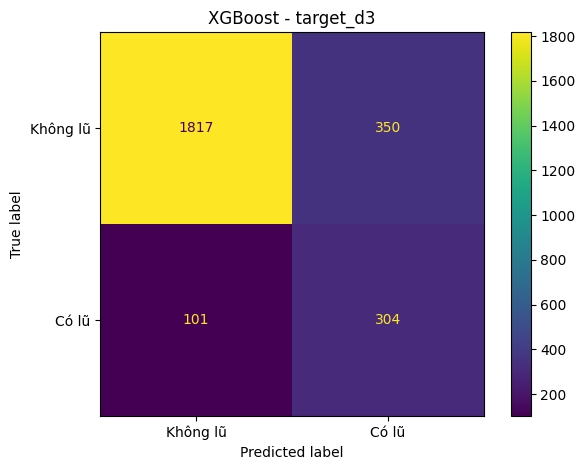

In [32]:
for target in target_cols:

    ConfusionMatrixDisplay.from_predictions(
        y_test[target],
        xgb_predictions[target],
        display_labels=[
            "Không lũ",
            "Có lũ"
        ]
    )

    plt.title(
        f"XGBoost - {target}"
    )

    plt.tight_layout()
    plt.show()

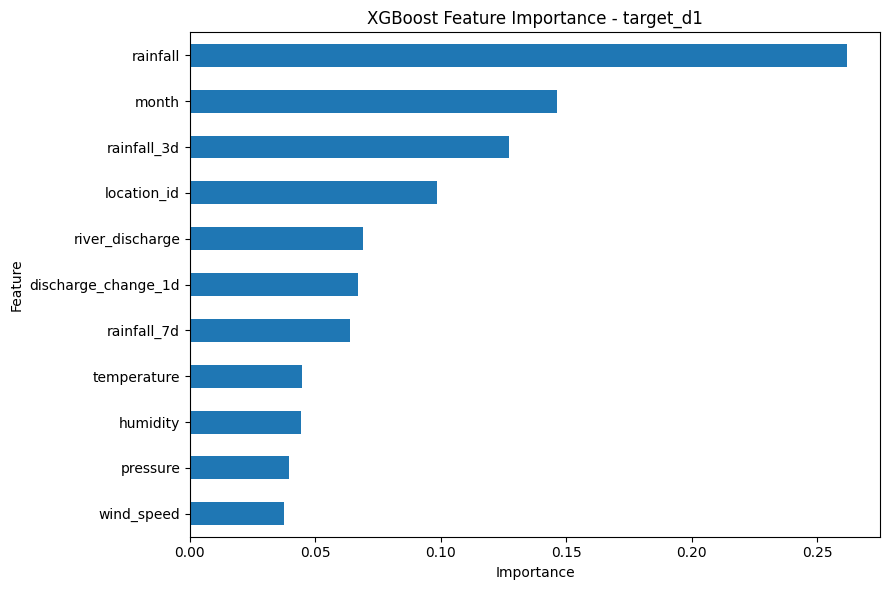

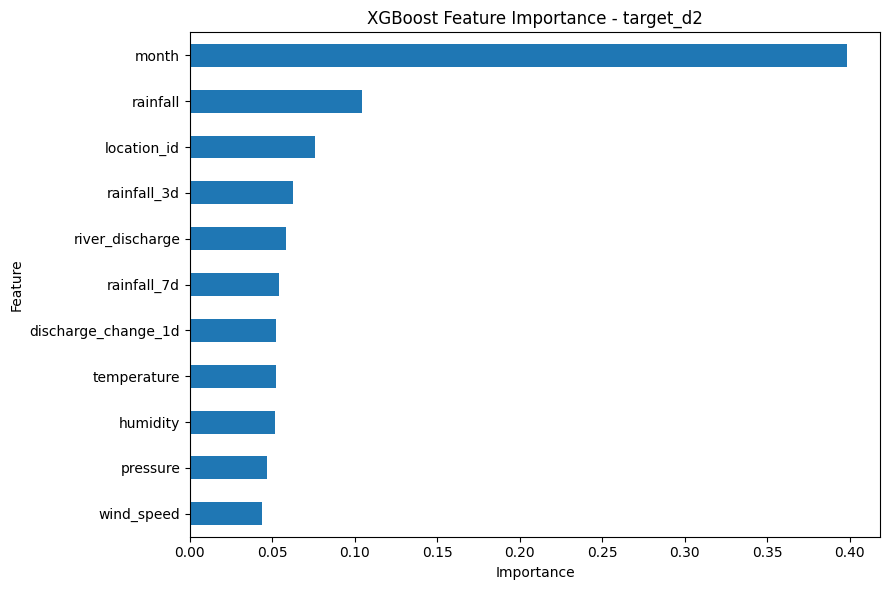

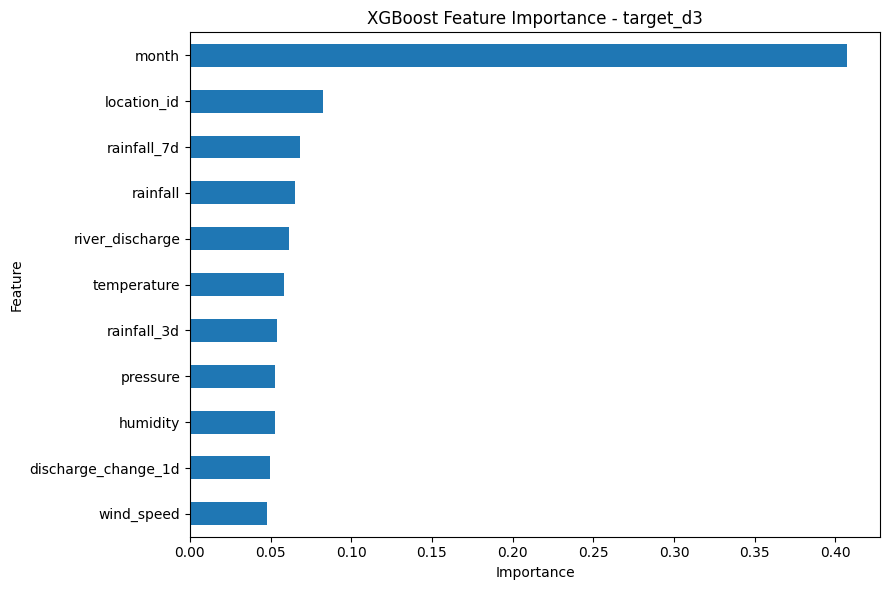

In [33]:
xgb_importance_tables = {}

for target in target_cols:

    importance_df = pd.DataFrame({
        "feature": feature_cols,
        "importance": (
            xgb_models[target]
            .feature_importances_
        )
    })

    importance_df = importance_df.sort_values(
        "importance",
        ascending=False
    )

    xgb_importance_tables[target] = importance_df

for target in target_cols:

    importance_df = (
        xgb_importance_tables[target]
        .sort_values(
            "importance",
            ascending=True
        )
    )

    importance_df.plot(
        kind="barh",
        x="feature",
        y="importance",
        figsize=(9, 6),
        legend=False
    )

    plt.title(
        f"XGBoost Feature Importance - {target}"
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")

    plt.tight_layout()
    plt.show()

#### Gộp kết quả 2 models

In [34]:
comparison_df = pd.concat(
    [
        rf_results_df,
        xgb_results_df
    ],
    ignore_index=True
)

comparison_df.round(4)

,model,target,accuracy,precision,recall,f1_score,roc_auc,pr_auc,true_negative,false_positive,false_negative,true_positive
0,Random Forest,target_d1,0.9343,0.8306,0.7346,0.7797,0.9652,0.8695,2104,61,108,299
1,Random Forest,target_d2,0.8993,0.7312,0.5749,0.6437,0.9192,0.7412,2079,86,173,234
2,Random Forest,target_d3,0.8616,0.5866,0.4099,0.4826,0.8657,0.5600,2050,117,239,166
3,XGBoost,target_d1,0.9086,0.6581,0.8796,0.7529,0.9648,0.8730,1979,186,49,358
4,XGBoost,target_d2,0.8713,0.5640,0.8231,0.6693,0.9253,0.7556,1906,259,72,335
5,XGBoost,target_d3,0.8247,0.4648,0.7506,0.5741,0.8695,0.5699,1817,350,101,304


In [35]:
comparison_table = comparison_df[
    [
        "model",
        "target",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc",
        "pr_auc",
        "false_negative"
    ]
]

comparison_table.round(4)

,model,target,accuracy,precision,recall,f1_score,roc_auc,pr_auc,false_negative
0,Random Forest,target_d1,0.9343,0.8306,0.7346,0.7797,0.9652,0.8695,108
1,Random Forest,target_d2,0.8993,0.7312,0.5749,0.6437,0.9192,0.7412,173
2,Random Forest,target_d3,0.8616,0.5866,0.4099,0.4826,0.8657,0.5600,239
3,XGBoost,target_d1,0.9086,0.6581,0.8796,0.7529,0.9648,0.8730,49
4,XGBoost,target_d2,0.8713,0.5640,0.8231,0.6693,0.9253,0.7556,72
5,XGBoost,target_d3,0.8247,0.4648,0.7506,0.5741,0.8695,0.5699,101


Trong dự báo lũ, cần chú ý:
- recall càng cao càng tốt (trong các lũ thật, đoán được bao nhiêu)
- FN càng thấp càng tốt

In [36]:
acceptable_models = comparison_df[
    comparison_df["precision"] >= 0.6
]

best_models = (
    acceptable_models
    .sort_values(
        "recall",
        ascending=False
    )
    .groupby("target")
    .first()
    .reset_index()
)

best_models

,target,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc,true_negative,false_positive,false_negative,true_positive
0,target_d1,XGBoost,0.908631,0.658088,0.879607,0.752892,0.964759,0.873036,1979,186,49,358
1,target_d2,Random Forest,0.899300,0.731250,0.574939,0.643741,0.919208,0.741150,2079,86,173,234
